# Construcción del modelo de clasificación de vinos

**Alumno:** Vicente Alberto Jahrift Alonso López  
**Matrícula:** AL07002967

**Objetivo:** construir y entrenar un modelo de Machine Learning con el dataset **Wine** de scikit-learn, usando cuatro características para clasificar los vinos en *Cabernet*, *Merlot* y *Pinot Noir*, y guardarlo como `modelo_wine.pkl`.

> Los nombres de los vinos se usan únicamente como etiquetas didácticas para las tres clases del dataset; no corresponden a variedades reales identificadas en los datos originales.

## Paso 1. Importar las librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Dataset, división de datos, escalamiento, Pipeline y SVM
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Evaluación del modelo
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Almacenamiento del modelo
import joblib
import os

## Paso 2. Cargar el dataset

In [2]:
wine = load_wine()

# Convertir los datos en un DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Agregar la variable objetivo
df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 3. Asignar nombres a las clases

| Clase original | Etiqueta didáctica |
|---|---|
| 0 | Cabernet |
| 1 | Merlot |
| 2 | Pinot Noir |

In [3]:
nombres_clases = {0: "Cabernet", 1: "Merlot", 2: "Pinot Noir"}

df["tipo_vino"] = df["target"].map(nombres_clases)

df[["target", "tipo_vino"]].head()

,target,tipo_vino
0,0,Cabernet
1,0,Cabernet
2,0,Cabernet
3,0,Cabernet
4,0,Cabernet


## Paso 4. Exploración inicial

In [4]:
print("Dimensiones del dataset:", df.shape)
print("Cantidad de variables (características):", len(wine.feature_names))

Dimensiones del dataset: (178, 15)
Cantidad de variables (características): 13


In [5]:
# Tipos de datos
df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
tipo_vino                           str
dtype: object

In [6]:
# Valores nulos por columna
print("Total de valores nulos:", df.isnull().sum().sum())
df.isnull().sum()

Total de valores nulos: 0


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
tipo_vino                       0
dtype: int64

In [7]:
# Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


tipo_vino
Cabernet      59
Merlot        71
Pinot Noir    48
Name: count, dtype: int64


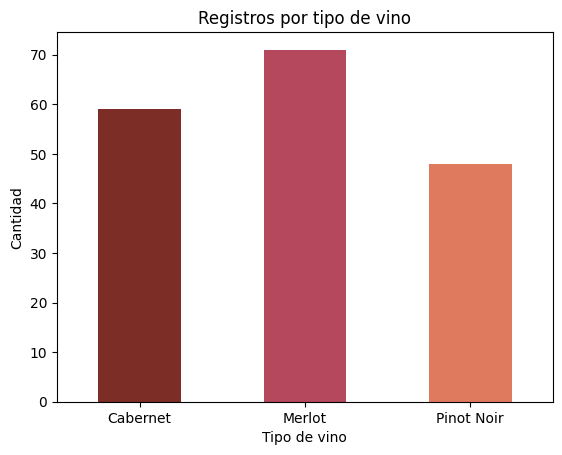

In [8]:
# Cantidad de registros por tipo de vino
conteo = df["tipo_vino"].value_counts().reindex(["Cabernet", "Merlot", "Pinot Noir"])
print(conteo)

conteo.plot(kind="bar", color=["#7b2d26", "#b5485d", "#e07a5f"])
plt.title("Registros por tipo de vino")
plt.xlabel("Tipo de vino")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

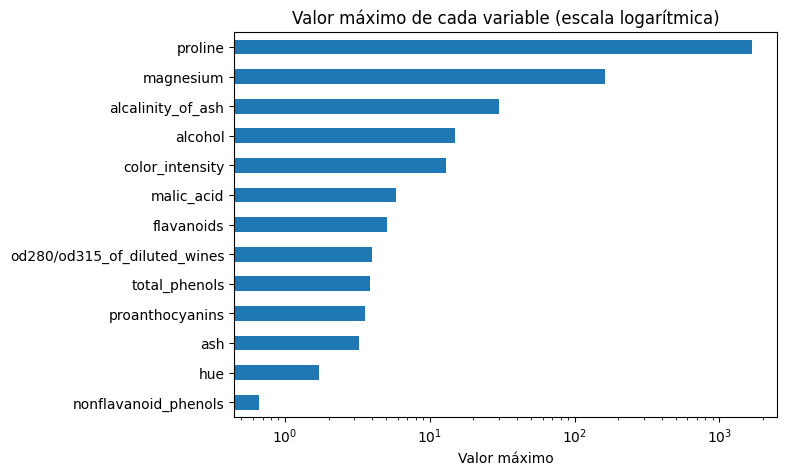

In [9]:
# Comparación de escalas: media y desviación estándar de cada variable
escalas = df[wine.feature_names].agg(["mean", "std", "min", "max"]).T.sort_values("max")
escalas.plot(y="max", kind="barh", logx=True, legend=False, figsize=(7, 5))
plt.title("Valor máximo de cada variable (escala logarítmica)")
plt.xlabel("Valor máximo")
plt.show()

### Preguntas para analizar

**¿Existen valores faltantes?**  
No. El conteo de nulos es 0 en todas las columnas, así que no es necesario imputar ni eliminar registros.

**¿Las tres clases contienen la misma cantidad de registros?**  
No. Cabernet tiene 59, Merlot 71 y Pinot Noir 48. El desbalance es moderado; por eso conviene estratificar la división de los datos (paso 6) para que cada conjunto conserve estas proporciones.

**¿Se observa alguna diferencia importante entre las escalas de las variables?**  
Sí, y es muy marcada. Por ejemplo, `proline` va aproximadamente de 278 a 1680, mientras que `hue` o `nonflavanoid_phenols` están por debajo de 2. Un SVM se basa en distancias, así que sin escalar las variables grandes (como `proline`) dominarían el modelo. Por eso se usa `StandardScaler`.

## Paso 5. Selección de características

| Variable | Descripción |
|---|---|
| alcohol | Contenido de alcohol |
| malic_acid | Ácido málico |
| color_intensity | Intensidad del color |
| proline | Concentración de prolina |

In [10]:
caracteristicas = ["alcohol", "malic_acid", "color_intensity", "proline"]

X = df[caracteristicas]
y = df["tipo_vino"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (178, 4)
Dimensiones de y: (178,)


## Paso 6. Conjuntos de entrenamiento y prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (142, 4)
X_test:  (36, 4)
y_train: (142,)
y_test:  (36,)


In [12]:
# Verificar que la estratificación mantiene las proporciones
pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Entrenamiento": y_train.value_counts(normalize=True),
    "Prueba": y_test.value_counts(normalize=True)
}).round(3)

,Original,Entrenamiento,Prueba
tipo_vino,,,
Merlot,0.399,0.401,0.389
Cabernet,0.331,0.331,0.333
Pinot Noir,0.270,0.268,0.278


### Preguntas para analizar

**¿Por qué no se utiliza el 100 % de los datos para entrenar?**  
Porque necesitamos datos que el modelo nunca haya visto para medir qué tan bien generaliza. Si evaluáramos con los mismos datos de entrenamiento, el resultado sería demasiado optimista y no detectaríamos el sobreajuste (que el modelo "memorice" en lugar de aprender).

**¿Qué función cumple la estratificación?**  
Garantiza que la proporción de cada clase sea la misma en el conjunto original, en entrenamiento y en prueba (como se ve en la tabla). Así ninguna clase queda sub-representada por azar, algo importante con un dataset pequeño (178 registros) y ligeramente desbalanceado.

## Paso 7. Crear el Pipeline

In [13]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


## Paso 8. Entrenar el modelo

In [14]:
modelo.fit(X_train, y_train)

print("Clases aprendidas por el modelo:", modelo.classes_)

Clases aprendidas por el modelo: ['Cabernet' 'Merlot' 'Pinot Noir']


**¿Por qué resulta conveniente incluir el escalamiento y el modelo dentro del mismo Pipeline?**

- El `StandardScaler` calcula la media y desviación estándar **solo con los datos de entrenamiento** y después aplica esa misma transformación a los datos de prueba y a datos nuevos. Esto evita la *fuga de datos* (data leakage).
- Cuando se hace una predicción, no hay que acordarse de escalar manualmente: el Pipeline lo hace solo.
- Al guardarlo con Joblib, el escalador y el SVM se guardan juntos en un solo archivo, por lo que el modelo recuperado funciona igual que el original.

## Paso 9. Predicciones

In [15]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})
comparacion["¿Correcto?"] = comparacion["Real"] == comparacion["Predicho"]

comparacion

,Real,Predicho,¿Correcto?
0,Cabernet,Cabernet,True
1,Pinot Noir,Merlot,False
2,Cabernet,Cabernet,True
3,Merlot,Pinot Noir,False
4,Merlot,Merlot,True
5,Cabernet,Cabernet,True
6,Cabernet,Cabernet,True
7,Merlot,Merlot,True
8,Merlot,Merlot,True
9,Pinot Noir,Pinot Noir,True


## Paso 10. Evaluación del modelo

In [16]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}  (promedio macro)")
print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}  (promedio macro)")
print(f"F1-score : {f1_score(y_test, y_pred, average='macro'):.4f}  (promedio macro)")

Accuracy : 0.9167
Precision: 0.9185  (promedio macro)
Recall   : 0.9095  (promedio macro)
F1-score : 0.9129  (promedio macro)


In [17]:
# Métricas por tipo de vino
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

    Cabernet     1.0000    1.0000    1.0000        12
      Merlot     0.8667    0.9286    0.8966        14
  Pinot Noir     0.8889    0.8000    0.8421        10

    accuracy                         0.9167        36
   macro avg     0.9185    0.9095    0.9129        36
weighted avg     0.9173    0.9167    0.9159        36



### Análisis por tipo de vino

*(El análisis se basa en los resultados de la celda anterior.)*

- **Precision**: de todos los vinos que el modelo dijo que eran de una clase, qué porcentaje realmente lo era.
- **Recall**: de todos los vinos que realmente eran de una clase, qué porcentaje encontró el modelo.
- **F1-score**: promedio armónico de precision y recall; resume ambas en un solo número.

- **Cabernet**: precision, recall y F1 de 1.00. El modelo identificó correctamente los 12 Cabernet de prueba y nunca confundió otro vino con Cabernet. Es la clase más fácil de separar con estas cuatro variables (tiende a tener alcohol y prolina altos).
- **Merlot**: precision 0.87 y recall 0.93. Encontró casi todos los Merlot (13 de 14), pero algunos vinos que predijo como Merlot en realidad eran Pinot Noir.
- **Pinot Noir**: precision 0.89 y recall 0.80. Es la clase con el desempeño más bajo: el modelo dejó escapar 2 de los 10 Pinot Noir, clasificándolos como Merlot. También es la clase con menos registros (48), lo cual puede influir.

En general, con **accuracy de 0.917** (33 de 36 aciertos) el modelo es bastante bueno considerando que usa solo 4 de las 13 variables disponibles.

## Paso 11. Matriz de confusión

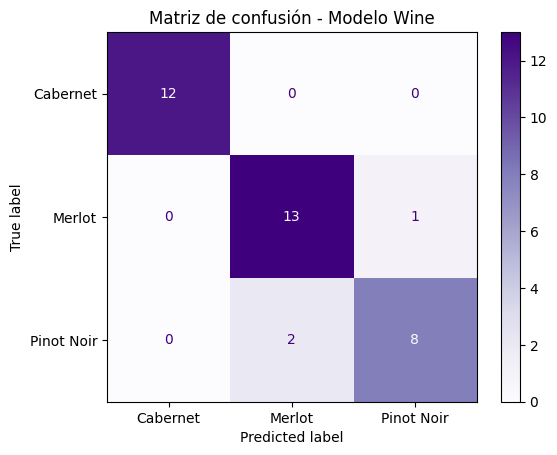

In [18]:
orden = ["Cabernet", "Merlot", "Pinot Noir"]
cm = confusion_matrix(y_test, y_pred, labels=orden)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden)
disp.plot(cmap="Purples")
plt.title("Matriz de confusión - Modelo Wine")
plt.show()

In [19]:
correctas = np.trace(cm)
errores = cm.sum() - correctas
print(f"Predicciones correctas: {correctas} de {cm.sum()}")
print(f"Errores de clasificación: {errores}")

# Detalle de los errores (fuera de la diagonal)
for i, real in enumerate(orden):
    for j, pred in enumerate(orden):
        if i != j and cm[i, j] > 0:
            print(f"  {cm[i, j]} vino(s) {real} clasificado(s) como {pred}")

Predicciones correctas: 33 de 36
Errores de clasificación: 3
  1 vino(s) Merlot clasificado(s) como Pinot Noir
  2 vino(s) Pinot Noir clasificado(s) como Merlot


### Interpretación

- **Predicciones correctas**: están en la diagonal principal; son 33 de 36 (12 Cabernet, 13 Merlot y 8 Pinot Noir).
- **Errores de clasificación**: 3 en total, fuera de la diagonal: 2 Pinot Noir predichos como Merlot y 1 Merlot predicho como Pinot Noir.
- **Clases con mayor confusión**: **Merlot y Pinot Noir**. Todos los errores ocurren entre estas dos clases, lo que indica que sus valores de alcohol, ácido málico, intensidad de color y prolina se traslapan. Cabernet, en cambio, no se confunde con ninguna.

## Paso 12. Probar un nuevo vino

In [20]:
nuevo_vino = pd.DataFrame({
    "alcohol": [13.5],
    "malic_acid": [1.8],
    "color_intensity": [5.2],
    "proline": [1000]
})

prediccion_original = modelo.predict(nuevo_vino)
print("Tipo de vino predicho:", prediccion_original[0])

Tipo de vino predicho: Cabernet


## Paso 13. Guardar el modelo

In [21]:
joblib.dump(modelo, "modelo_wine.pkl")

# Comprobar que el archivo se generó correctamente
if os.path.exists("modelo_wine.pkl"):
    print("Archivo generado correctamente")
    print(f"Tamaño: {os.path.getsize('modelo_wine.pkl')} bytes")
else:
    print("El archivo no se generó")

Archivo generado correctamente
Tamaño: 4677 bytes


## Paso 14. Recuperar el modelo

In [22]:
modelo_recuperado = joblib.load("modelo_wine.pkl")
modelo_recuperado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [23]:
prediccion_recuperada = modelo_recuperado.predict(nuevo_vino)

print("Predicción antes de guardar  :", prediccion_original[0])
print("Predicción modelo recuperado :", prediccion_recuperada[0])
print("¿Son iguales?", prediccion_original[0] == prediccion_recuperada[0])

# Comprobación extra: el modelo recuperado da las mismas predicciones en todo el conjunto de prueba
print("¿Mismas predicciones en X_test?", (modelo_recuperado.predict(X_test) == y_pred).all())

Predicción antes de guardar  : Cabernet
Predicción modelo recuperado : Cabernet
¿Son iguales? True
¿Mismas predicciones en X_test? True


## Reflexión final

**Entrenar un modelo** es el proceso en el que el algoritmo aprende a partir de los datos: el `StandardScaler` calcula medias y desviaciones, y el SVM busca los hiperplanos que mejor separan las clases. Requiere los datos de entrenamiento, consume tiempo y cómputo, y se hace una sola vez (o cada vez que se quiera actualizar con datos nuevos).

**Utilizar un modelo previamente entrenado** significa cargar ese conocimiento ya aprendido (los parámetros guardados en `modelo_wine.pkl`) y solo aplicarlo con `predict()` a datos nuevos. No se necesitan los datos originales ni volver a entrenar; es rápido y da exactamente los mismos resultados, como se comprobó en el paso 14. Así es como se usan los modelos en producción, por ejemplo dentro de una API.

### Flujo completo

**Datos** (dataset Wine) → **preparación** (DataFrame, etiquetas `tipo_vino`, selección de 4 características, división 80/20 estratificada) → **Pipeline** (`StandardScaler` + `SVC` lineal) → **entrenamiento** (`fit` con datos de entrenamiento) → **evaluación** (accuracy, precision, recall, F1 y matriz de confusión con datos de prueba) → **Joblib** (`dump` / `load`) → **`modelo_wine.pkl`**